# Введение

Одним из основных видов машинного обучения является группа классических методов машинного обучения. Среди таких методов разделяют 2 категории: "Обучение с учителем" и "Обучение без учителя".

В случае обучения с учителем у нас есть вектор X с признаками (атрибутами) и вектор Y c правильными ответами. При обучении без учителя у нас есть только объекты $X=\{x_1, x_2, ..., x_m\} \in \mathbb{R^n}$ и нет ответов к ним, то есть мы имеем неразмеченную выборку.

In [ ]:
Image(url= "https://thumb.tildacdn.com/tild3533-6161-4335-a633-643631363962/-/resize/760x/-/format/webp/8.jpeg", width=600)

Обучение без учителя можно поделить на три основных типа задач:
* кластеризация
* уменьшение размерности (обощение)
* поиск правил (ассоциация)

Самой известной и популярной, пожалуй, является **кластеризация**.

Примеры применения кластеризации:
* Сегментация рынка (типов покупателей, лояльности)
* Объединение близких точек на карте
* Сжатие изображений
* Анализ и разметки новых данных
* Детекторы аномального поведения

Постановка задачи:
* Дано: объекты $X=\{x_1, x_2, ..., x_m\} \in \mathbb{R^n}$
* Требуется разбить это множество объектов на группы таким образом, чтобы элементы внутри одной группы были похожи друг на друга, а элементы из разных групп отличались. Такие группы похожих объектов мы будем называть **кластеры**.

In [ ]:
from IPython.display import Image
from IPython.core.display import HTML
Image(url= "http://neerc.ifmo.ru/wiki/images/7/74/Clusters.png", width=200)

Следует отличать методы кластеризации от методов классификации. Методы классификации — это методы обучения с учителем. Это значит, что для каждого объекта нам известна его истинная метка принадлежности к классу. Затем, имея истинные метки, предсказания алгоритма и некоторую функцию потерь, алгоритмы классификации как-то подстраиваются так, чтобы допускать меньше ошибок на данных. Алгоритмы же кластеризации никак не используют информацию об истинных метках объектов и оперируют лишь похожестью объекта. Ну а что такое похожесть, в каждом алгоритме кластеризации определяется по-своему.

Основная цель кластеризации заключается в том, чтобы выявить структуру в данных. С помощью методов кластеризации мы можем автоматически найти группу похожих объектов, возможно, выделить аномалии, какие-то изолированные объекты, которые требуют дополнительного изучения или выбрасывания из данных, и кластеризация позволяет провести более детальный анализ самих кластеров. Иногда бывает полезно построить отдельные модели на каждом кластере вместо того, чтобы строить одну модель на всех данных и получить какой-то мусор.

Существует очень много методов кластеризации.
*    методы кластеризации на основе прототипов
*    иерархические методы кластеризации
*    плотностные методы кластеризации
*    ...

*Методы разбиения на основе прототипов* заключаются в том, что кластеры характеризуются некоторым базовым элементом или прототипом.  Например, в методе k-средних кластер характеризуется центроидом — центром масс объектов, из которых он состоит. Обычно в результате применения алгоритмов из этой группы мы получаем строгое разбиение всех наших объектов на кластеры, то есть одному объекту соответствует одна метка кластера.

*Иерархические алгоритмы* позволяют получить целую структуру вложенных друг в друга кластеров. Иногда это бывает полезно для того, чтобы понять вообще структуру наших данных от начала до конца.

*Плотностные методы кластеризации* действуют совершенно иначе. В них кластер определяется, как область с большой плотностью точек, с большой плотностью объектов. Такая формулировка кластера позволяет выявлять произвольные формы кластеров и выделять объекты-выбросы, то есть элементы, вокруг которых нет других точек.

В рамках данной лабораторной работы мы рассмотрим метод k-means (к-средних), относящийся к методам кластеризации на основе прототипов.

# Метод К-средних

Итак, у нас есть некоторой множество объектов $X=\{x_1, x_2, ..., x_m\} \in \mathbb{R^n}$. Мы хотим разделить это множество на $K$ кластеров, каждый из которых характеризуется центроидом:

Кластер $C_k\leftrightarrow$ центроид $\mu_k$

 Объект относится к соответствующему кластеру, если его центроид находится ближе других центроидов к этому объекту:

объект $x_i\in C_k \Leftrightarrow \mu_k = arg\ \underset{\mu_j}{min}||x_i - \mu_i||^2$

Будем кластеризовывать объекты таким образом, чтобы минимизировать сумму квадратов расстояния между объектом и ближайшим к нему центроидом по всем кластерам:

$L(C)=\sum\limits_{j=1}^k\sum\limits_{x_i \in C_j}{||x_i-\mu_j||^2}$

Если взять производную по $\mu$, то становится понятно, что лучше всего выражать центроид именно как центр масс объектов, которые относятся к соответствующему кластеру.

$\mu_k=\frac{\sum\limits_{x_i \in C_k}x_i}{|C_k|}$

Теперь у нас есть формулировка критерия и мы знаем, как считать центроид.  Но для того, чтобы найти глобальный минимум этого функционала нужно перебирать все возможные разбиения объектов на к-кластеров, что, конечно же, не так интересно. Спасает нас алгоритм к-средних, который позволяет найти локальный минимум этого критерия.

















### Алгоритм k-средних

Вход: Объекты $X$, $k$ - количество кластеров
1.    **Инициализация центроидов** $\mu_1, \mu_2, ..., \mu_k$
2.    **Обновление кластеров:** объекты приписываются к ближайшему центроиду
3.    **Обновление центроидов:** пересчет положения центроидов как центр масс объектов, которые лежат в соответствующем кластере

Шаги 2 и 3 продолжаются до тех пор пока не выполнятся некоторые правила остановок, например, будет достигнуто какое-то максимальное количество итераций или пока кластеры не перестанут меняться.

In [ ]:
Image(url= "https://stanford.edu/~cpiech/cs221/img/kmeansViz.png", width=600)

Пояснения к рисунку: алгоритм K-средних. Примеры обучения показаны точками, а центроиды  показаны крестиками.
*    (а) Исходный набор данных.
*    (b) Случайные начальные центроидов.
*    (c) Приписываем объекты к ближайшему центроиду (на картинке окрашиваем их в соответствующий цвет)
*    (d) Пересчитываем положение цетроида как центра масс для всех объектов, приписанных к данному центроиду, и перемещаем его в новое положение
*    (e) Приписываем объекты к ближайшему центроиду (на картинке окрашиваем их в соответствующий цвет)
*    (f) Пересчитываем положение цетроида как центра масс для всех объектов, приписанных к данному центроиду, и перемещаем его в новое положение

Останавливаем выполнение алгоритма, так как положение центроидов не меняется. Кластеризация закончена

Результирующее разбиение на кластеры, которое получается после алгоритма к-средних, в основном, зависит от следующих факторов.
*    начальная инициализация центроидов. Оказывается, что на одним и тех же данных при одних и тех же k, но при разной инициализации мы можем получить совершенно разное разбиение на кластеры.
*    определение количества кластеров данных

# Варианты начальной инциализации

Базовые варианты начальной инициализации центроидов:
1.    выбрать k-случайных объектов в наших данных в качестве центроидов и уже с этих центроидов начинать следующие шаги алгоритма.
2.    использовать k-кластеров полученных после применения иерархической кластеризации с методом Уорда.
3.    метод К-Means++: Первый центроид мы будем выбирать случайным образом среди всех точек в данных, которые у нас есть. Для каждой точки мы будем рассчитывать расстояние до ближайшего центроида, который ранее был уже нами инициализирован. В качестве следующего центроида мы будем выбирать также точки наших данных, но с вероятностью пропорционально как раз этому расстояние, которое мы посчитали на шаге предыдущем.



[K-means++](https://www.youtube.com/watch?v=BIQDlmZDuf8)

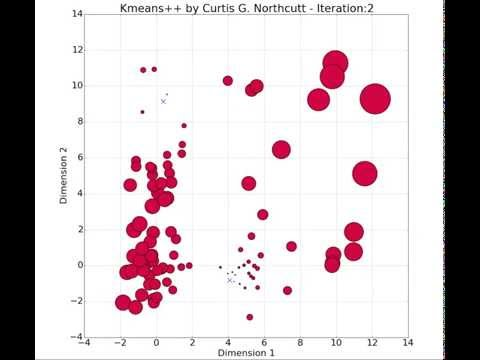

In [7]:
from IPython.display import YouTubeVideo
YouTubeVideo('BIQDlmZDuf8')

Данный ролик иллюстрирует начальную инициализацию центроидов по методу k-means++

Пояснения к ролику:
*    шаг 0: начальные данные
*    шаг 1: среди всех точек случайным образом выбираем положение 1-го центроида  (крестик в левом верхнем углу). Пересчитываем квадрат расстояния для каждой точки от выбранного центроида. Размер точки теперь пропорционален квадрату расстояния.
*    шаг 2: выбираем следующий центроид так, чтобы вероятность выбора точки была пропорциональна вычисленному для неё квадрату расстояния ([подробнее](https://ru.wikipedia.org/wiki/K-means%2B%2B) )

шаг 1 и 2 повторяются пока не будут выбраны все центроиды

# Определение количества кластеров данных

Есть несколько вариантов выбора количества кластеров $k$:
*    использовать не стандартный метод k-mean, а модифицированный (X-means или intelligent k-means), который $k$ вычисляет автоматически
*    использовать меры качеств кластеризации: для каждого k и разбиения мы будем считать меру качества кластеризации и в соответствии с этой мерой выберем лучшее разбиение и, соответственно, лучшее k.
*    воспользоваться некоторыми эвристиками (например, методом Локтя)

#### Метод локтя

Для каждого k будем считать значение критерия k-means: $$L^{(k)}(C)=\sum\limits_{j=1}^k\sum\limits_{x_i \in C_j}{||x_i-\mu_j||^2}$$
Если расположить эти значения на графике, то мы получим примерно такую убывающая функцию.

In [ ]:
Image(url= "https://blog.bioturing.com/wp-content/uploads/2018/10/1_dChOocbcsLLT1fcxTxj2Ng.png", width=500)

Нам нужно найти такое k, начиная с которого значение критерия k-means будет убывать не слишком быстро. Этот эффект очень визуально похож на локоть и отсюда, собственно, название этого метода (Метод Локтя). Например, для данных на рисунке выше, таким k будет k равное 4. Важно понимать, что все эти эвристики и меры качества в кластеризации носят лишь рекомендательный характер.

In [10]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
X,y = make_blobs(n_samples=100, random_state=1)

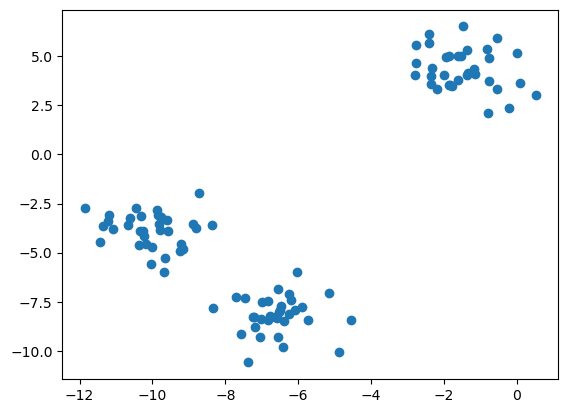

In [7]:
plt.scatter(X[:,0], X[:,1])

In [11]:
from sklearn.cluster import KMeans
kmeansModel = KMeans(n_clusters=2)

Обучим модель

In [ ]:
kmeansModel.fit(X)

После обучения мы можем получить метки кластеров, взяв атрибут класса KMeans под названием labels_

In [ ]:
labels = kmeansModel.labels_

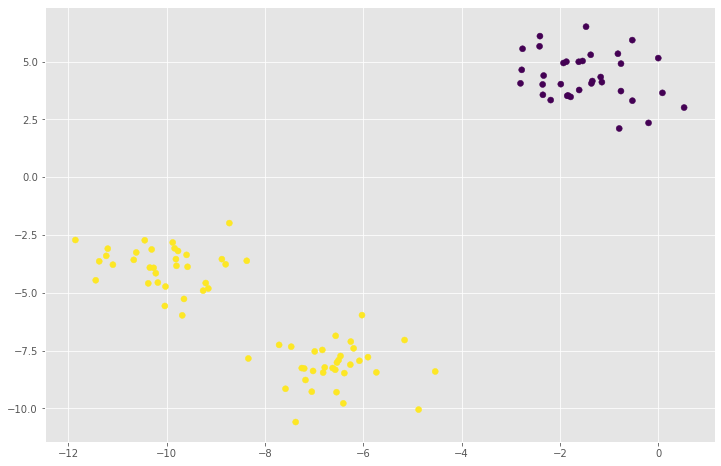

In [ ]:
plt.scatter(X[:,0], X[:,1], c=labels)

In [ ]:
criteries = []
for k in range(2,10):
  kmeansModel=KMeans(n_clusters=k, random_state=3)
  kmeansModel.fit(X)
  criteries.append(kmeansModel.inertia_)

In [ ]:
print(criteries)

[661.5698490972003, 156.28289251170003, 130.96121900774804, 114.59023246367273, 98.16373044247607, 80.68742756289457, 68.84208083839681, 59.709534350860274]


Для метода локтя мы должны построить график для полученных значений. По оси X у нас буду значения k, по оси у - вычисленные значения критерия

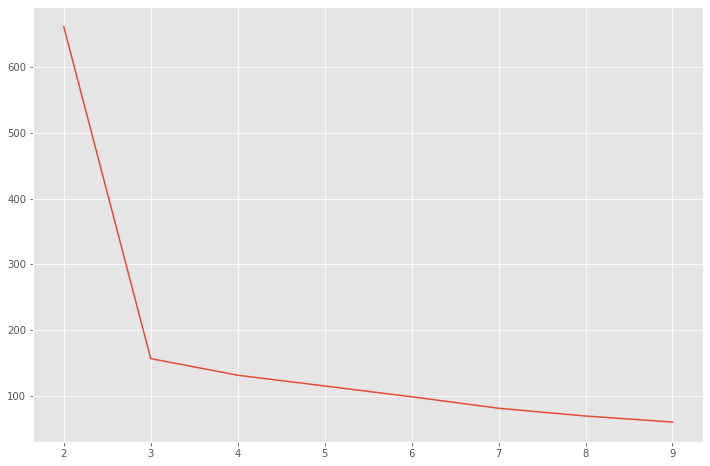

In [ ]:
plt.plot(range(2,10), criteries)

как видно из графика, оптимальное количество кластеров в данном случае - 3

Применим метод для 3 кластеров и посмотрим результат

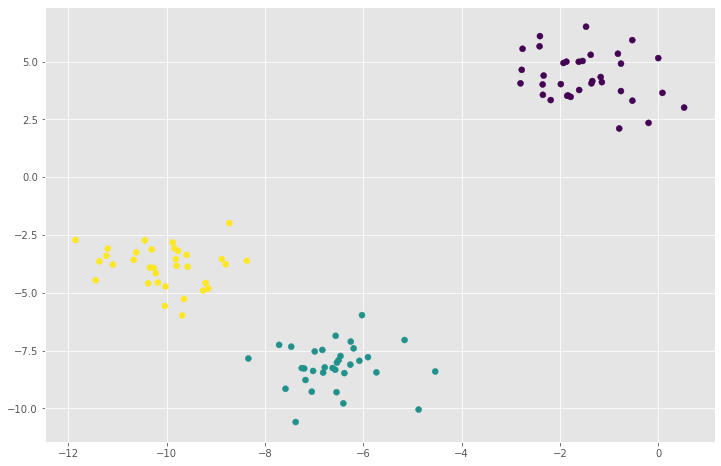

In [ ]:
kmeansModel=KMeans(n_clusters=3, random_state=0)
kmeansModel.fit(X)
labels = kmeansModel.labels_
plt.scatter(X[:,0], X[:,1], c=labels)

#### Достоинства и недостатки алгоритма:

Сильные стороны алгоритма:

* Сравнительно высокая эффективность при простоте реализации
* Высокое качество кластеризации
* Возможность распараллеливания
* Существование множества модификаций

Недостатки алгоритма:

* Количество кластеров является параметром алгоритма
* Чувствительность к начальным условиям (Инициализация центров кластеров в значительной степени влияет на результат кластеризации)
* Чувствительность к выбросам и шумам (Выбросы, далекие от центров настоящих кластеров, все равно учитываются при вычислении их центров)
* Возможность сходимости к локальному оптимуму (Итеративный подход не дает гарантии сходимости к оптимальному решению)
* Использование понятия "среднего" (Алгоритм неприменим к данным, для которых не определено понятие "среднего", например, категориальным данным)
* слабая классификация сложных данных (ленточных кластеров, вложенных, пересекающихся и т.д.)

В качестве примера различных алгоритмов приведем результаты работы различных алгоритмов кластеризации для различных типов данных (k-means - самый первый столбик)

In [ ]:
Image(url= "http://neerc.ifmo.ru/wiki/images/thumb/2/28/Cluster_comparison.png/800px-Cluster_comparison.png", width=800)

Если посмотреть на картинку, можно увидеть, что на данных примерах самая точная кластеризация у метода DBSCAN. Давайте рассмотрим этот метод

## Метод DBSCAN

DBSCAN (Density-based spatial clustering of applications with noise, плотностной алгоритм пространственной кластеризации с присутствием шума), как следует из названия, оперирует плотностью данных.

Суть метода (максимально упрощенно):
предположим перед лекцией несколько групп студентов находятся в коридоре и ждут, когда освободится аудитория. Предположим, каждый студент - это отдельная точка. Кто-то стоит один, кто-то кучкуется группой, кто-то стоит вдоль стен. Как же выделить в такой толпе кластеры?
Находим трёх любых близко стоящих человека и говорим им взяться за руки. Затем они начинают брать за руку тех, до кого могут дотянуться. Так по цепочке, пока никто больше не сможет взять кого-то за руку — это и будет первый кластер. Повторяем, пока не поделим всех. Те, кому вообще некого брать за руку — это выбросы, аномалии. Более подробно можно посмотреть [здесь](https://habr.com/ru/post/322034/)


Визуализация этого метода на примере не очень простых данных. Цветом выделены разные кластеры, выбросы (точки, не вошедшие ни в один кластер) остались неокрашенными.

![dbscanUrl](https://cdn-images-1.medium.com/max/1600/1*tc8UF-h0nQqUfLC8-0uInQ.gif "DBSCAN")

главные недостатки DBSCAN — неспособность соединять кластеры через проёмы, и, наоборот, способность связывать явно различные кластеры через плотно населённые перемычки.

Значительное влияние на работу алгоритма DBSCAN оказывают два его входных параметра: eps -радиус окрестности (это максимальное расстояние на котором две точки считаются соседями и могут быть отнесены к одному кластеру) и min_samples - минимальное количество точек, образующих кластер. Подбор этих параметров - важная часть настройки данного метода. Посмотрим это на примере небольшого набора "синтетических" данных

In [ ]:
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
X, y = make_blobs(random_state=0, n_samples=30)

Визуализируем полученные данные (заодно посмотрим, как это делать с помощью библиотеки matplotlib)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('ggplot')
plt.rcParams['figure.figsize']=(12,8)

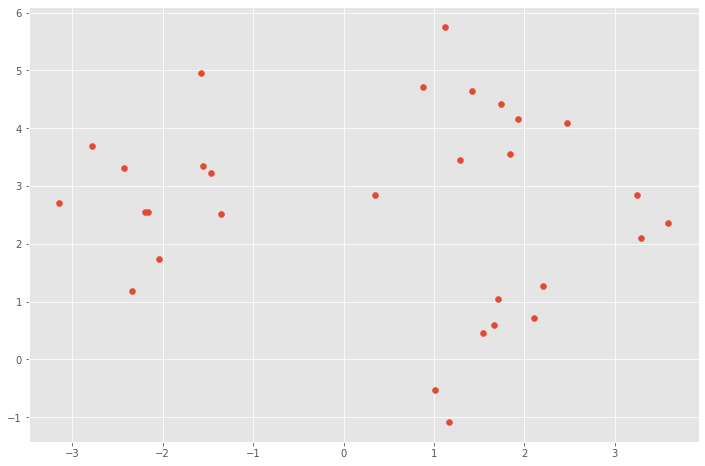

In [ ]:
plt.scatter(X[:,0], X[:,1])

Так выглядят наши данные. Давайте посмотрим на сколько кластеров поделит алгоритм DBSCAN такие данные в зависимости от параметров eps и n_samples. Сначала запустим алгоритм с параметрами по умолчанию(eps=0.5, min_samples=5).

In [ ]:
dbscan = DBSCAN()
clusters = dbscan.fit_predict(X)
print("Принадлежность к кластерам:\n{}".format(clusters))

Принадлежность к кластерам:
[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1]


Мы видим, что всем точкам была присвоена метка -1, что означает "шум". Кластеры созданы не были. Причина этого - слишком маленькое eps и достаточно большое n_samples

Увеличим eps и уменьшим min_samples

In [ ]:
dbscan = DBSCAN(eps=3, min_samples=2)
clusters = dbscan.fit_predict(X)
print("Принадлежность к кластерам:\n{}".format(clusters))

Принадлежность к кластерам:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


Теперь все точки объединились в один кластер с номером 0 (тоже не очень удачный вариант).
Подберите параметры так, чтобы было выделено несколько кластеров

In [ ]:
dbscan = DBSCAN(eps=1, min_samples=3)
clusters = dbscan.fit_predict(X)
print("Принадлежность к кластерам:\n{}".format(clusters))

Принадлежность к кластерам:
[-1  0  0  0  1  2 -1  0  1  0  0  0  0  3  2  2  1 -1  0  2  3  1  2  2
  3  1 -1 -1  0  2]


Визуализируйте полученные данные:

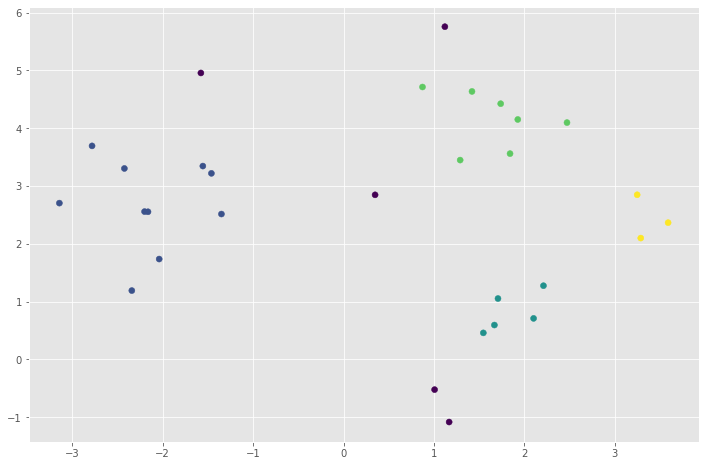

In [ ]:
plt.scatter(X[:,0], X[:,1], c=clusters)

## Подбор параметра eps для DBSCAN

Для DBSCAN очень важно правильно выбрать параметр `eps` — радиус окрестности, в пределах которого точки считаются соседями.

Если `eps` слишком маленький, алгоритм будет считать многие точки шумом.  
Если `eps` слишком большой, разные кластеры могут слиться в один.

Один из популярных способов подобрать `eps` — построить **k-distance graph**: для каждой точки считаем расстояние до `k`-го ближайшего соседа, сортируем эти расстояния и ищем место резкого роста — «локоть». Обычно берут:

\[
k = min\_samples
\]


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.datasets import make_moons

### 1. Подготовим данные

В этом ноутбуке уже используется переменная `X`. Перед DBSCAN признаки лучше масштабировать, потому что алгоритм основан на расстояниях.

In [ ]:
X, y_true = make_moons(

    n_samples=500,

    noise=0.07,

    random_state=42

)

# Для DBSCAN почти всегда нужно масштабировать признаки.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Частое практическое правило: min_samples >= число признаков + 1
min_samples = X_scaled.shape[1] + 1

print("Размер данных:", X_scaled.shape)
print("min_samples =", min_samples)

Размер данных: (500, 2)
min_samples = 3


### 2. Строим k-distance graph

На графике ищем точку, где линия начинает резко расти. Значение по оси Y около этого «локтя» можно взять как `eps`.

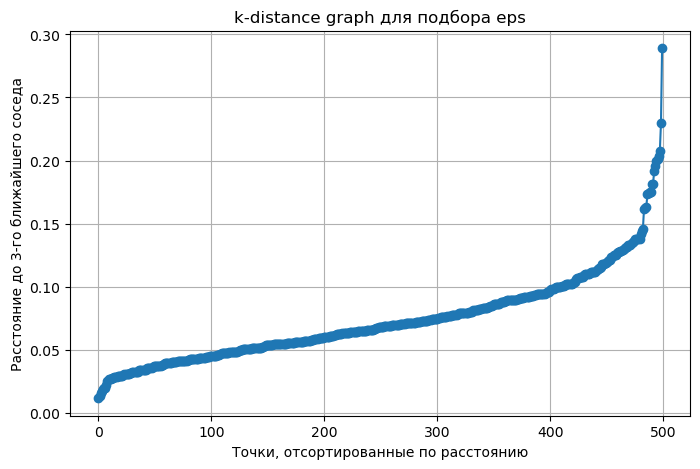

In [ ]:
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_scaled)

distances, indices = neighbors.kneighbors(X_scaled)

# расстояние до k-го ближайшего соседа
k_distances = distances[:, -1]
k_distances_sorted = np.sort(k_distances)

plt.figure(figsize=(8, 5))
plt.plot(k_distances_sorted, marker='o')
plt.xlabel("Точки, отсортированные по расстоянию")
plt.ylabel(f"Расстояние до {min_samples}-го ближайшего соседа")
plt.title("k-distance graph для подбора eps")
plt.grid(True)
plt.show()

### 3. Запускаем DBSCAN с выбранным eps

После графика нужно выбрать `eps` вручную. В примере ниже значение можно менять и смотреть, как меняется результат.

Попробуйте несколько значений, например `0.3`, `0.5`, `0.8`, `1.0`, `1.5`, `2.0`.

In [ ]:
eps = 0.15

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels_dbscan = dbscan.fit_predict(X_scaled)

n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = np.sum(labels_dbscan == -1)

print("eps =", eps)
print("min_samples =", min_samples)
print("Метки кластеров:", np.unique(labels_dbscan))
print("Количество кластеров без учета шума:", n_clusters)
print("Количество шумовых точек:", n_noise)

eps = 0.15
min_samples = 3
Метки кластеров: [-1  0  1  2  3]
Количество кластеров без учета шума: 4
Количество шумовых точек: 7


### 4. Визуализация результата

Метка `-1` означает шум — точки, которые DBSCAN не отнес ни к одному кластеру.

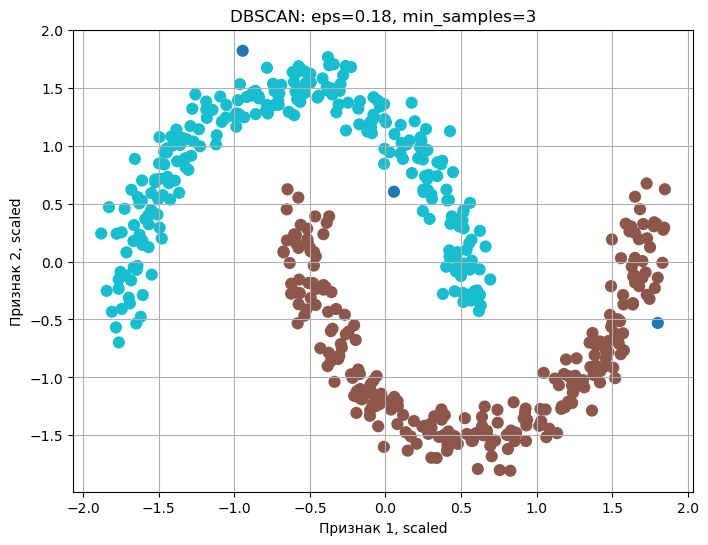

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_dbscan, cmap="tab10", s=60)
plt.xlabel("Признак 1, scaled")
plt.ylabel("Признак 2, scaled")
plt.title(f"DBSCAN: eps={eps}, min_samples={min_samples}")
plt.grid(True)
plt.show()

### 5. Оценка качества DBSCAN

Для расчета метрик часто исключают шумовые точки с меткой `-1`, иначе шум будет восприниматься как отдельный кластер.

In [ ]:
mask = labels_dbscan != -1

if n_clusters > 1 and len(set(labels_dbscan[mask])) > 1:
    sil = silhouette_score(X_scaled[mask], labels_dbscan[mask])
    dbi = davies_bouldin_score(X_scaled[mask], labels_dbscan[mask])
    ch = calinski_harabasz_score(X_scaled[mask], labels_dbscan[mask])

    print("Silhouette Score:", round(sil, 3), "— чем больше, тем лучше")
    print("Davies-Bouldin Index:", round(dbi, 3), "— чем меньше, тем лучше")
    print("Calinski-Harabasz Index:", round(ch, 3), "— чем больше, тем лучше")
else:
    print("Метрики нельзя посчитать: после исключения шума осталось меньше двух кластеров.")

Silhouette Score: 0.039 — чем больше, тем лучше
Davies-Bouldin Index: 3.019 — чем меньше, тем лучше
Calinski-Harabasz Index: 179.767 — чем больше, тем лучше


### 6. Перебор нескольких значений eps

Ниже можно автоматически проверить несколько значений `eps` и сравнить:

- сколько получилось кластеров;
- сколько точек стало шумом;
- какой получился `Silhouette Score` без учета шума.

In [ ]:
eps_values = np.arange(0.1, 3.1, 0.1)
results = []

for eps_candidate in eps_values:
    model = DBSCAN(eps=eps_candidate, min_samples=min_samples)
    labels_candidate = model.fit_predict(X_scaled)

    n_clusters_candidate = len(set(labels_candidate)) - (1 if -1 in labels_candidate else 0)
    n_noise_candidate = np.sum(labels_candidate == -1)
    noise_percent = n_noise_candidate / len(labels_candidate) * 100

    mask_candidate = labels_candidate != -1

    if n_clusters_candidate > 1 and len(set(labels_candidate[mask_candidate])) > 1:
        sil_candidate = silhouette_score(X_scaled[mask_candidate], labels_candidate[mask_candidate])
    else:
        sil_candidate = np.nan

    results.append({
        "eps": round(eps_candidate, 2),
        "clusters": n_clusters_candidate,
        "noise_points": int(n_noise_candidate),
        "noise_percent": round(noise_percent, 2),
        "silhouette_without_noise": round(sil_candidate, 3) if not np.isnan(sil_candidate) else None
    })

results_df = pd.DataFrame(results)
results_df.head(30)

,eps,clusters,noise_points,noise_percent,silhouette_without_noise
0,0.1,24,51,10.2,0.277
1,0.2,2,2,0.4,0.385
2,0.3,2,0,0.0,0.386
3,0.4,2,0,0.0,0.386
4,0.5,1,0,0.0,NaN
5,0.6,1,0,0.0,NaN
6,0.7,1,0,0.0,NaN
7,0.8,1,0,0.0,NaN
8,0.9,1,0,0.0,NaN
9,1.0,1,0,0.0,NaN


### 7. Графики для сравнения eps

Хорошее значение `eps` обычно является компромиссом:

- кластеров не слишком много и не слишком мало;
- шум есть, но его не слишком много;
- `Silhouette Score` достаточно высокий;
- результат визуально похож на реальные группы.

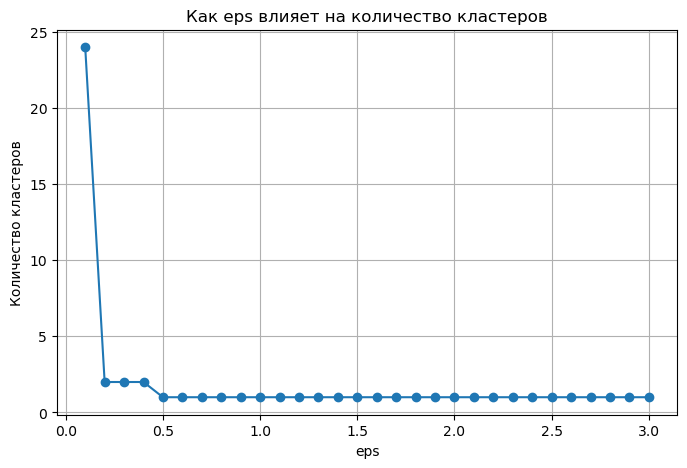

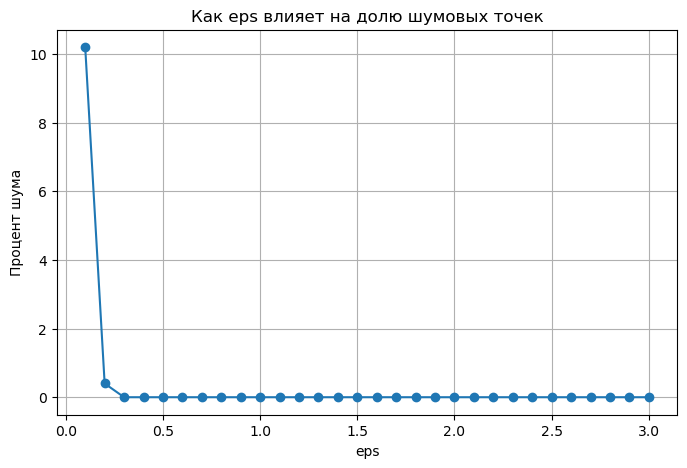

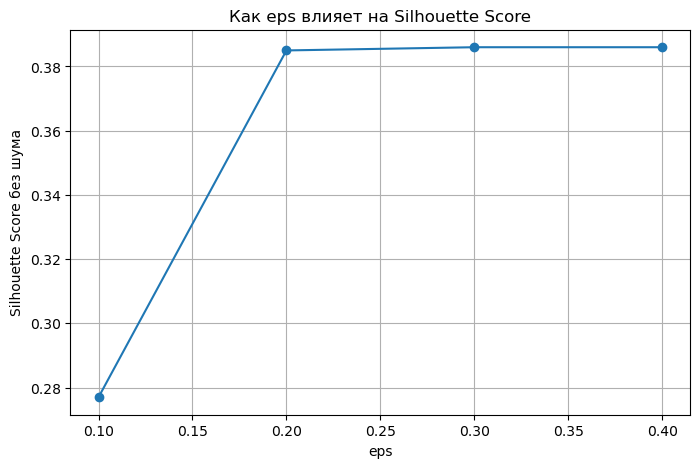

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(results_df["eps"], results_df["clusters"], marker="o")
plt.xlabel("eps")
plt.ylabel("Количество кластеров")
plt.title("Как eps влияет на количество кластеров")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(results_df["eps"], results_df["noise_percent"], marker="o")
plt.xlabel("eps")
plt.ylabel("Процент шума")
plt.title("Как eps влияет на долю шумовых точек")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(results_df["eps"], results_df["silhouette_without_noise"], marker="o")
plt.xlabel("eps")
plt.ylabel("Silhouette Score без шума")
plt.title("Как eps влияет на Silhouette Score")
plt.grid(True)
plt.show()

### Вывод

Для подбора `eps` в DBSCAN удобно использовать такой порядок:

1. Масштабировать признаки.
2. Выбрать `min_samples`.
3. Построить k-distance graph.
4. Взять `eps` около «локтя» на графике.
5. Проверить результат визуально.
6. Посмотреть количество кластеров, количество шума и метрики качества.

Важно помнить: не существует универсального идеального `eps`. Его выбор зависит от данных и смысла задачи.


---

# Метрики оценки качества кластеризации

После того как алгоритм выделил кластеры, нужно понять, насколько результат хороший. В кластеризации нет одного универсального критерия качества, поэтому обычно смотрят несколько метрик и визуализацию.

Метрики делятся на две группы:

1. **Внутренние метрики** — используют только признаки `X` и найденные метки кластеров. Истинные классы не нужны.
2. **Внешние метрики** — сравнивают найденные кластеры с настоящими метками `y_true`, если они есть.




### Коэффициент силуэта

Показывает, насколько объект похож на свой кластер по сравнению с ближайшим чужим кластером.

$$
s = \frac{b - a}{\max(a, b)}
$$

где:

- \(a\) — среднее расстояние от объекта до точек своего кластера;
- \(b\) — среднее расстояние до точек ближайшего другого кластера.

Интерпретация:

- ближе к **1** — хорошо;
- около **0** — кластеры пересекаются;
- меньше **0** — часть объектов, вероятно, попала не в тот кластер.

### Индекс Дэвиса-Болдина

Оценивает отношение разброса внутри кластеров к расстоянию между кластерами.

- **меньше = лучше**.

### Индекс Калински-Харабаза (VRC)

Сравнивает разброс между кластерами и разброс внутри кластеров.

- **больше = лучше**.

### Inertia / WCSS

Часто используется для K-means. Это сумма квадратов расстояний от точек до центров своих кластеров.

- **меньше = лучше**, но при увеличении числа кластеров значение почти всегда уменьшается;
- поэтому inertia часто используют вместе с **методом локтя**.
